## Logistic Regression

Logistic Regression is a statistical model used for **binary classification tasks**. Despite its name, it's primarily used for classification rather than traditional regression.

It works by modeling the probability that a given input belongs to a certain class. This is achieved by applying a **sigmoid function** to a linear combination of features. The output of the sigmoid function is a probability value ranging between 0 and 1.

**Key characteristics:**
*   **Output:** A probability score (0 to 1).
*   **Decision Boundary:** A threshold (commonly 0.5) is used to convert the probability into a class label (e.g., if probability > 0.5, classify as 1; otherwise, as 0).
*   **Linear Model:** It's a linear model at its core, but the sigmoid function transforms the output to be suitable for probabilities.
*   **Simplicity:** It's a relatively simple and interpretable algorithm, making it a good baseline for classification problems, especially when data is linearly separable.

### The Role of the Sigmoid Function

The sigmoid function (also known as the logistic function) is fundamental to Logistic Regression. It serves several critical purposes:

1.  **Transforms Linear Output to Probability:** In Logistic Regression, a linear combination of input features and their corresponding weights is first calculated (similar to linear regression: `z = w0 + w1*x1 + w2*x2 + ...`). This linear output `z` can take any real value from negative infinity to positive infinity. However, for classification, we need an output that represents a probability, which must be constrained between 0 and 1.

2.  **Squashes the Output:** The sigmoid function, mathematically defined as `σ(z) = 1 / (1 + e^(-z))`, takes this real-valued `z` and 'squashes' it into a value strictly between 0 and 1. Specifically:
    *   As `z` approaches positive infinity, `σ(z)` approaches 1.
    *   As `z` approaches negative infinity, `σ(z)` approaches 0.
    *   When `z = 0`, `σ(z) = 0.5`.

3.  **Interpretable Output:** The transformed output from the sigmoid function can then be directly interpreted as the probability that the input instance belongs to the positive class (e.g., P(Y=1|X)). For example, if the sigmoid output is 0.8, it signifies an 80% probability that the instance belongs to the positive class.

4.  **Introduces Non-linearity for Classification:** While the core model structure is linear (the weighted sum of inputs), the sigmoid function introduces a non-linearity at the output stage. This non-linearity is crucial for creating a smooth, S-shaped curve that effectively maps continuous input values to a probability space, making it suitable for binary classification tasks where a clear decision boundary is required based on a probability threshold.

In [1]:
import numpy as np

def sigmoid(z):
  """Computes the sigmoid (logistic) function for a given input z."""
  return 1 / (1 + np.exp(-z))

# Demonstrate the sigmoid function
print(f"Sigmoid of 0: {sigmoid(0):.4f}")
print(f"Sigmoid of 2: {sigmoid(2):.4f}")
print(f"Sigmoid of -2: {sigmoid(-2):.4f}")
print(f"Sigmoid of 10: {sigmoid(10):.4f}")
print(f"Sigmoid of -10: {sigmoid(-10):.4f}")

Sigmoid of 0: 0.5000
Sigmoid of 2: 0.8808
Sigmoid of -2: 0.1192
Sigmoid of 10: 1.0000
Sigmoid of -10: 0.0000


#Program 1: Pass or Fail Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [3]:
Hours_Studied=np.array([2,3,4,5,6,7,8,9])
Result=np.array([0,0,0,0,0,1,1,1])



In [6]:
model = LogisticRegression()
model.fit(Hours_Studied.reshape(-1, 1), Result)

In [7]:
# Reshape Hours_Studied to a 2D array as required by sklearn
X = Hours_Studied.reshape(-1, 1)
y = Result

# Train the Logistic Regression model
model.fit(X, y)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
hours_to_predict = np.array([[5.5]])

# Predict the probability of passing
probability = model.predict_proba(hours_to_predict)[0][1]

print(f"The probability of passing for 5.5 hours of study is: {probability:.4f}")

The probability of passing for 5.5 hours of study is: 0.2345


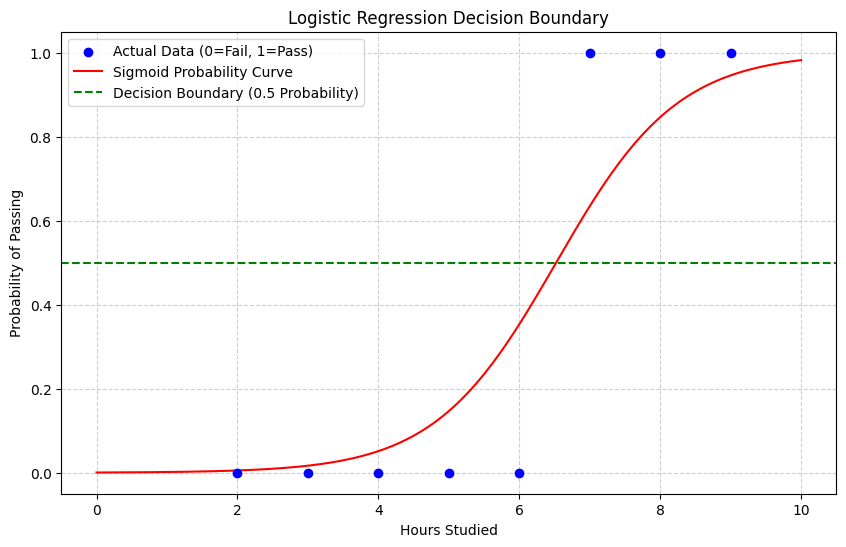

In [9]:
import matplotlib.pyplot as plt

# Generate a range of hours for plotting the decision boundary
plot_hours = np.linspace(0, 10, 300).reshape(-1, 1)

# Predict probabilities for the generated hours
probabilities = model.predict_proba(plot_hours)[:, 1]

# Plot the data points
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data (0=Fail, 1=Pass)', zorder=3)

# Plot the sigmoid curve
plt.plot(plot_hours, probabilities, color='red', label='Sigmoid Probability Curve')

# Plot the decision boundary at 0.5 probability
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Boundary (0.5 Probability)')

# Set labels and title
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#2. Product Rating Prediction

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [11]:
data = {
    "Product_Name": ["Laptop", "Mobile", "Laptop", "Tablet", "Mobile",
                     "Tablet", "Laptop", "Mobile", "Tablet", "Laptop"],
    "Feedback_Rate": [85, 90, 75, 80, 95, 70, 88, 92, 78, 98],
    "State": ["Bihar", "Delhi", "Bihar", "UP", "Delhi",
              "UP", "Bihar", "Delhi", "UP", "Bihar"],
    "Rating": [4.2, 4.8, 3.8, 4.0, 4.9, 3.7, 4.5, 4.8, 4.1, 5.0]
}

df = pd.DataFrame(data)


In [12]:
df.head()

,Product_Name,Feedback_Rate,State,Rating
0,Laptop,85,Bihar,4.2
1,Mobile,90,Delhi,4.8
2,Laptop,75,Bihar,3.8
3,Tablet,80,UP,4.0
4,Mobile,95,Delhi,4.9


In [13]:
le_product = LabelEncoder()
le_state = LabelEncoder()

df['Product_Name'] = le_product.fit_transform(df['Product_Name'])
df['State'] = le_state.fit_transform(df['State'])



In [14]:
#Feature and Target
X = df[['Product_Name', 'Feedback_Rate', 'State']]
y = df['Rating']

In [15]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred=model.predict(X_test)

In [18]:
# Evaluation
print("Model Evaluation")
print("-" * 30)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Model Evaluation
------------------------------
MAE : 0.12484779608734531
MSE : 0.018790023134302936
RMSE: 0.13707670529416344
R2 Score: 0.8466120560465067


In [21]:
print("\nAvailable Products:", list(le_product.classes_))
product = input("Enter Product Name: ")

print("Available States:", list(le_state.classes_))
state = input("Enter State: ")

feedback = float(input("Enter Feedback Rate (%): "))


Available Products: ['Laptop', 'Mobile', 'Tablet']
Enter Product Name: Laptop
Available States: ['Bihar', 'Delhi', 'UP']
Enter State: Bihar
Enter Feedback Rate (%): 90


In [22]:
# Encode User Input
product_encoded = le_product.transform([product])[0]
state_encoded = le_state.transform([state])[0]

# Predict Rating
predicted_rating = model.predict([[product_encoded, feedback, state_encoded]])

print(f"\nPredicted Product Rating: {predicted_rating[0]:.2f} / 5")


Predicted Product Rating: 4.57 / 5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#Program ::Diabetic

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
data = {
    "Pregnancies": [1,3,2,5,4,6,2,7,8,3,5,1],
    "Glucose": [85,120,95,140,130,160,100,170,180,110,145,90],
    "BloodPressure": [70,80,75,85,82,90,72,95,100,78,88,74],
    "SkinThickness": [20,25,22,30,28,35,21,38,40,24,32,23],
    "BMI": [22.5,28.4,24.2,31.5,29.8,35.1,23.6,36.8,38.5,26.4,32.7,23.8],
    "DiabetesPedigreeFunction": [0.25,0.45,0.30,0.60,0.55,0.72,0.28,0.80,0.95,0.40,0.65,0.27],
    "Age": [21,35,24,45,40,52,26,58,60,30,48,23],
    "Outcome": [0,1,0,1,1,1,0,1,1,0,1,0]
}

df = pd.DataFrame(data)

In [25]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,70,20,22.5,0.25,21,0
1,3,120,80,25,28.4,0.45,35,1
2,2,95,75,22,24.2,0.30,24,0
3,5,140,85,30,31.5,0.60,45,1
4,4,130,82,28,29.8,0.55,40,1


In [26]:
# Features and Target
# -----------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [27]:
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
# Train Logistic Regression Model
# -----------------------------
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [30]:
y_pred = model.predict(X_test)


In [31]:
# -----------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Accuracy : 1.0

Confusion Matrix
[[2 0]
 [0 1]]


In [32]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))



Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [33]:
# User Prediction
# -----------------------------
preg = int(input("Pregnancies: "))
glucose = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

new_data = scaler.transform([[preg, glucose, bp, skin, bmi, dpf, age]])

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("\nPrediction: Diabetic")
else:
    print("\nPrediction: Not Diabetic")

Pregnancies: 2
Glucose: 120
Blood Pressure: 80
Skin Thickness: 25
BMI: 28
Diabetes Pedigree Function: 0.45
Age: 35

Prediction: Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Program :Iris Flower Classification

In [34]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Load Iris Dataset
# -----------------------------
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Train Logistic Regression Model
# -----------------------------
model = LogisticRegression()

model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# -----------------------------
# User Prediction
# -----------------------------
sepal_length = float(input("Enter Sepal Length (cm): "))
sepal_width = float(input("Enter Sepal Width (cm): "))
petal_length = float(input("Enter Petal Length (cm): "))
petal_width = float(input("Enter Petal Width (cm): "))

new_flower = scaler.transform([[sepal_length, sepal_width, petal_length, petal_width]])

prediction = model.predict(new_flower)

print("\nPredicted Flower Species:", iris.target_names[prediction[0]])

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Enter Sepal Length (cm): 5.1
Enter Sepal Width (cm): 3.5
Enter Petal Length (cm): 1.4
Enter Petal Width (cm): 0.2

Predicted Flower Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
